## Analyse the mouse brain multi-omics dataset.

In [1]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

'/pri_exthome/zhouwg/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import pandas as pd
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

In [3]:
# read data
import scipy.sparse as sp

dataset='spatial_atac_rna_seq_mouse_brain'
root_dir = '/pri_exthome/zhouwg/project/spatial_data/spatial_multi-omics'
file_fold = os.path.join(root_dir, str(dataset))
adata_rna = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2.h5ad')
adata_rna.var_names_make_unique()
adata_rna

AnnData object with n_obs × n_vars = 9215 × 22914
    obs: 'RNA_clusters', 'ATAC_clusters', 'batch'
    obsm: 'spatial'
    layers: 'counts'

In [4]:
adata_rna.obs = adata_rna.obs.drop(['ATAC_clusters'],axis=1)
adata_rna

AnnData object with n_obs × n_vars = 9215 × 22914
    obs: 'RNA_clusters', 'batch'
    obsm: 'spatial'
    layers: 'counts'

In [5]:
adata_atac = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2_atac.h5ad')
adata_atac.var_names_make_unique()
adata_atac

AnnData object with n_obs × n_vars = 9215 × 121068
    obs: 'RNA_clusters', 'ATAC_clusters', 'batch'
    obsm: 'spatial'
    layers: 'counts'

In [6]:
adata_atac.var_names

Index(['chr1:3094734-3095650', 'chr1:3119757-3120179', 'chr1:3120267-3120653',
       'chr1:3121314-3122051', 'chr1:3264998-3265766', 'chr1:3292462-3293293',
       'chr1:3294044-3295081', 'chr1:3300717-3301474', 'chr1:3301682-3302319',
       'chr1:3309769-3310662',
       ...
       'JH584304.1:106380-107258', 'JH584304.1:112856-113752',
       'GL456216.1:13410-14374', 'GL456216.1:16007-16700',
       'GL456216.1:16825-17441', 'GL456216.1:31908-32576',
       'GL456216.1:43983-44510', 'GL456216.1:48771-49683',
       'JH584292.1:12571-13497', 'JH584295.1:1163-1976'],
      dtype='object', length=121068)

In [7]:
# 读取metadata csv文件
meta = pd.read_csv(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2_cell_type_annotations.csv', index_col=0)
meta

,ATAC_clusters,predicted.celltype
CTAAGGTCTTGCTGGA,A6,MGL
CTAAGGTCACACAGAA,A2,ITL23GL
CTAAGGTCACAGCAGA,A6,MGL
CTAAGGTCACCTCCAA,A2,ITL23GL
CTAAGGTCACGCTCGA,A5,ITL23GL
...,...,...
GAACAGGCGATGAATC,A5,VEC
GAACAGGCGCCAAGAC,A5,VEC
GAACAGGCCGGAAGAA,A5,VLMC
GAACAGGCGTGACAAG,A2,VPIA


In [8]:
# add meta data
adata_rna.obs = adata_rna.obs.join(meta)
adata_rna

AnnData object with n_obs × n_vars = 9215 × 22914
    obs: 'RNA_clusters', 'batch', 'ATAC_clusters', 'predicted.celltype'
    obsm: 'spatial'
    layers: 'counts'

In [9]:
# 假设 atac_var_name 是 adata 的一个属性，已经是一个 pandas Series
atac_var_name = adata_atac.var_names  # 假设 var_names 中存储了你需要处理的数据

# 分割每个元素
split_data = atac_var_name.str.split(':|-', expand=True).to_frame(index=False)
split_data.index = atac_var_name
# 将分割后的数据转换为 DataFrame 并命名列
split_data.columns = ['chr', 'start', 'end']

# 将处理后的 DataFrame 存储到 adata.var 中
adata_atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": adata_rna, "atac": adata_atac})
mdata

MuData object with n_obs × n_vars = 9215 × 143982
  2 modalities
    rna:	9215 x 22914
      obs:	'RNA_clusters', 'batch', 'ATAC_clusters', 'predicted.celltype'
      obsm:	'spatial'
      layers:	'counts'
    atac:	9215 x 121068
      obs:	'RNA_clusters', 'ATAC_clusters', 'batch'
      var:	'chr', 'start', 'end'
      obsm:	'spatial'
      layers:	'counts'

### Integrating spatially resolved transcriptomics data using Garfield

In [10]:
# set workdir #
workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_multimodal/mouse_brain'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata,
    profile='spatial',
    data_type='multi-modal',
    sub_data_type=['rna', 'atac'],
    sample_col=None,
    weight=0.8,
    ## Preprocessing options
    graph_const_method='Squidpy', # mu_std, Radius, KNN, Squidpy
    genome='mm10',
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000,
    n_components=50,
    n_neighbors=5,
    metric='euclidean',
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,
    ## Model options
    augment_type='svd', # svd
    svd_q=5,
    use_FCencoder=False,
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2,
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=False,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=256, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1.0, #
    lambda_edge_recon=50., #
    lambda_latent_adj_recon_loss=200.,
    lambda_omics_recon_mmd_loss=0.2,
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=0,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_multimodal/mouse_brain


In [11]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 15628 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
6450/9215 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
5530/5530 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...


/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


In [12]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 8293
Number of validation nodes: 922
Number of training edges: 25989
Number of validation edges: 2887
Edge batch size: 4096
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.6237; val_auprc_score: 0.6360; val_best_acc_score: 0.5914; val_best_f1_score: 0.6688; train_kl_reg_loss: 1569127.6935; train_edge_recon_loss: 52219.2274; train_gene_expr_recon_loss: 710909.2946; train_lambda_latent_adj_recon_loss: 372631.1518; train_lambda_latent_contrastive_instanceloss: 7.8368; train_lambda_latent_contrastive_clusterloss: 3.7058; train_global_loss: 2704898.9196; train_optim_loss: 2704898.9196; val_kl_reg_loss: 41.7703; val_edge_recon_loss: 41093.1367; val_gene_expr_recon_loss: 312072.8750; val_lambda_latent_adj_recon_loss: 126713.9062; val_lambda_latent_contrastive_instanceloss: 7.5319; val_lambda_latent_contrastive_clusterloss: 3.6890; val_global_loss: 479932.9062; va

In [13]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [14]:
# Compute latent Leiden clustering
latent_leiden_resolution = 0.5
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
latent_key = "garfield_latent"

sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
len(model.adata.obs[latent_cluster_key].unique())

14

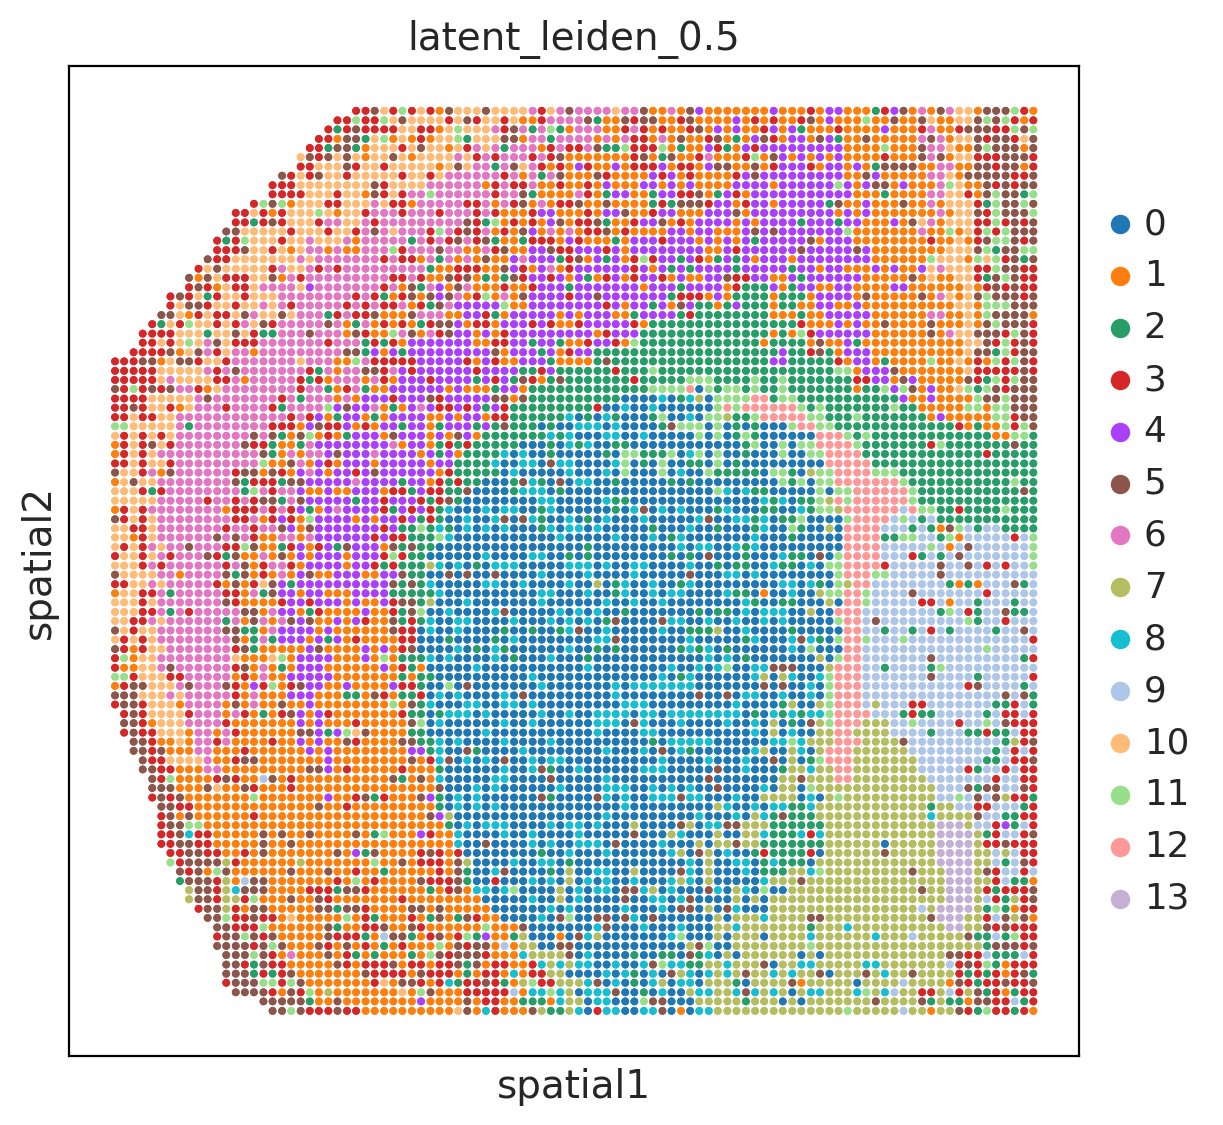

In [15]:
import squidpy as sq
sc.settings.set_figure_params(dpi=100, facecolor='white')

sq.pl.spatial_scatter(model.adata, color=latent_cluster_key, shape=None, figsize=(6, 6))

### Visualize Garfield Latent Space

In [22]:
import re

from matplotlib import pyplot as plt
import matplotlib
matplotlib.use("Agg") #使用非交互式的后端生成图像文件

def pic(pdf):
    searchObj = re.search( r'(.*).pdf', pdf)
    png = f"{searchObj.group(1)}.png"
    plt.savefig(pdf, bbox_inches="tight")
    plt.savefig(png, bbox_inches="tight", dpi=300)
    plt.close()

In [16]:
model.adata.obsm['spatial'][:, 0] *= -1  # 翻转 x 坐标 手动修正
model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正

<Axes: title={'center': 'Garfield Niches'}, xlabel='spatial1', ylabel='spatial2'>

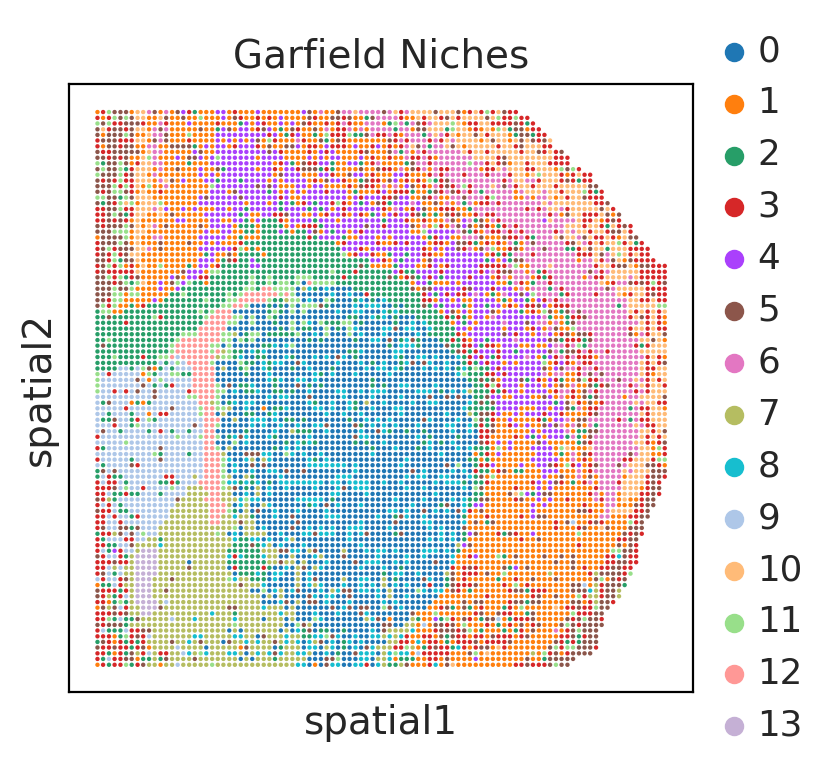

In [19]:
sc.settings.set_figure_params(dpi=100, facecolor='white')

import matplotlib.pyplot as plt
# model.adata.obsm['spatial'][:, 1] *= -1  # 翻转 y 坐标 手动修正
sc.pl.embedding(model.adata, basis='spatial', color=latent_cluster_key,
                title='Garfield Niches', s=10, show=False)
# plt.gca().invert_yaxis()  # 翻转 y 轴
# plt.show()
# pic(os.path.join(workdir, "01.spatial_plot_niche.pdf"))

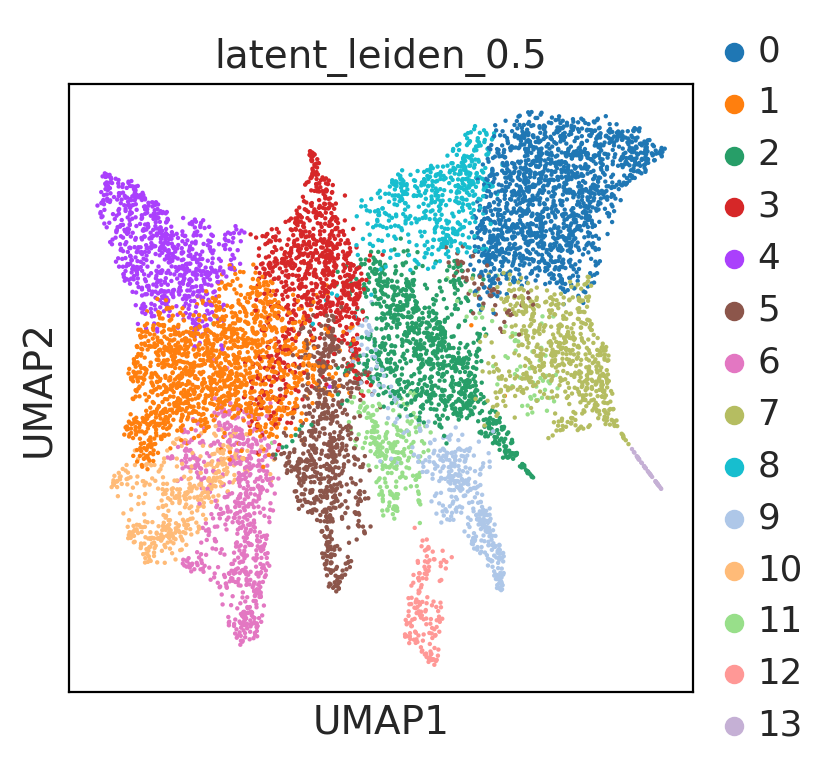

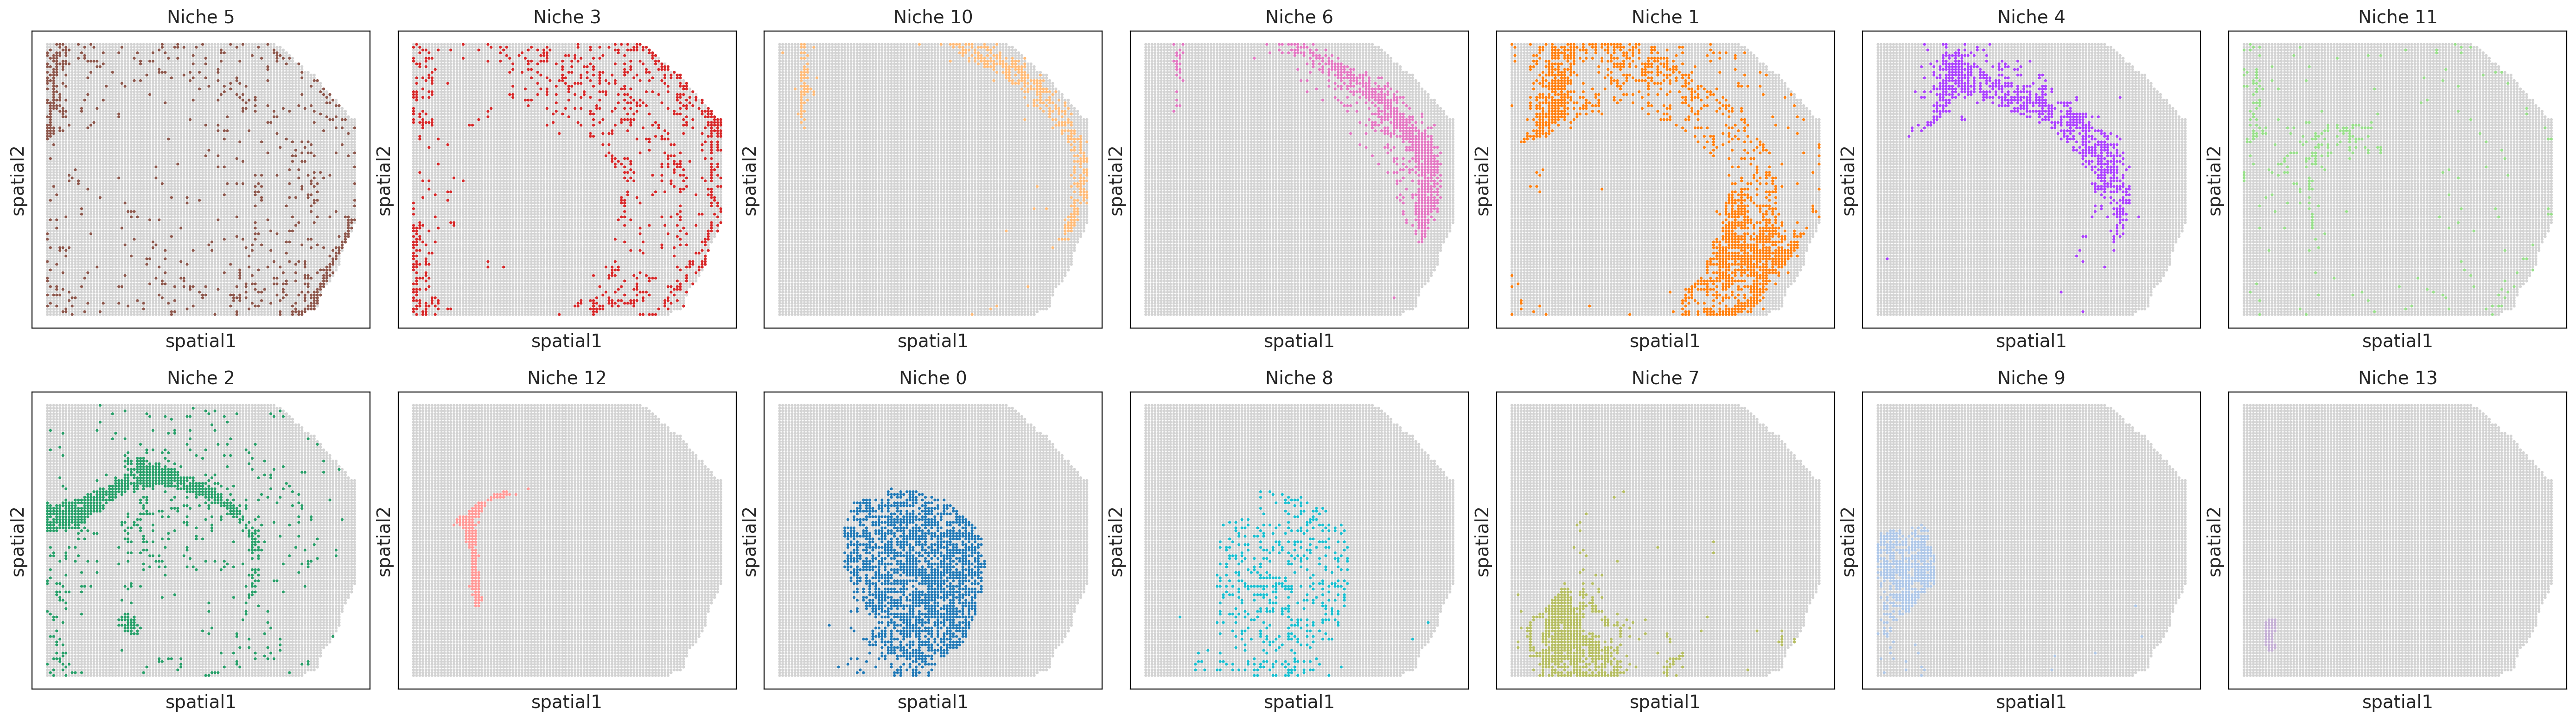

In [20]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

adata_batch = model.adata#[model.adata.obs['batch'] == batch].copy()
sc.pl.umap(adata_batch, color=[latent_cluster_key],
           s=10, show=False, ncols=2, wspace=0.3)

cluster_list = list(adata_batch.obs[latent_cluster_key].unique()) # ['0', '1', '3']
highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    2, math.ceil(len(cluster_list) / 2), figsize=(2 * len(cluster_list), 8)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[int(cluster)]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[int(cluster)], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"Niche {cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
# plt.show()
# pic(os.path.join(workdir, "03.spatial_plot_each_niche.pdf"))

In [42]:
## niche 注释
cluster2annotation = {
    '0': 'cp', #
    '1': 'ctx', #
    '2': 'ccg/aco', #
    '3': 'aca', #
    '4': 'ctx', #
    '5': 'aca',
    '6': 'ctx', #
    '7': 'acb', #
    '8': 'cp', #
    '9': 'ls', #
    '10': 'ctx', #
    '11': 'ctx/aca',
    '12': 'vl',
    '13': 'islm'
}
model.adata.obs['niche_type'] = model.adata.obs[latent_cluster_key].map(cluster2annotation).astype('category')

In [43]:
## niche 注释
cluster2annotation = {
    '0': '0-cp', #
    '1': '1-ctx', #
    '2': '2-ccg/aco', #
    '3': '3-aca', #
    '4': '4-ctx', #
    '5': '5-aca',
    '6': '6-ctx', #
    '7': '7-acb', #
    '8': '8-cp', #
    '9': '9-ls', #
    '10': '10-ctx', #
    '11': '11-ctx/aca',
    '12': '12-vl',
    '13': '13-islm'
}
model.adata.obs['niche_type_sub'] = model.adata.obs[latent_cluster_key].map(cluster2annotation).astype('category')

In [ ]:
# ## 改变 categories的顺序
# print(model.adata.obs['niche_type'].cat.categories)
# new_order = ['CL','LP','Stratum', 'Corpus_callosum', 'MH&LH',
#              'Stria_medullaris', 'CA1', 'DG', 'CA2&CA3', 'V3']
# model.adata.obs['niche_type'] = pd.Categorical(model.adata.obs['niche_type'],
#                                                categories=new_order, ordered=True)

In [46]:
# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(11, 5))
sc.pl.umap(model.adata, color='niche_type_sub', ax=ax_list[0], title='Garfield Niches',
           s=20, show=False,legend_loc=None)
sc.pl.embedding(model.adata, basis='spatial', color='niche_type_sub', ax=ax_list[1],
                title='Garfield Niches', s=20, show=False)
# plt.gca().invert_yaxis()  # 翻转 y 轴
plt.tight_layout(w_pad=0.3)
# plt.show()
pic(os.path.join(workdir, "02.spatial_plot_niche_concat.pdf"))

In [47]:
## 提取特定的batch数据集
import math
import matplotlib.pyplot as plt

adata_batch = model.adata#[model.adata.obs['batch'] == batch].copy()
latent_cluster_key = 'niche_type'

cluster_list = ['ccg/aco', 'vl', 'islm', 'acb', 'ls']
highlight_color = adata_batch.uns[f'{latent_cluster_key}_colors']
default_color = 'lightgray'  # 为其他细胞设置灰色
fig, ax_list = plt.subplots(
    1, len(cluster_list), figsize=(20, 4.5)
)
ax_list = ax_list.flatten()  # 展平以便在循环中逐一使用

tmp = adata_batch.copy()
for cluster, ax in zip(cluster_list, ax_list):
    # 设置所有细胞颜色为灰色
    tmp.obs['temp_color'] = default_color
    # 将特定 cluster 设置为高亮颜色
    cluster_cells = tmp.obs[latent_cluster_key] == cluster
    cluster_index = cluster_list.index(cluster)
    tmp.obs.loc[cluster_cells, 'temp_color'] = highlight_color[cluster_index]

    # 绘制空间图
    sc.pl.embedding(
        tmp,
        basis='spatial',
        color='temp_color',
        palette=[highlight_color[cluster_index], default_color],
        ax=ax,
        show=False,
        s=20,
        title=f"{cluster}",
        legend_loc=None
    )

plt.tight_layout(w_pad=0.3)
pic(os.path.join(workdir, "03.spatial_plot_each_niche.pdf"))

In [28]:
ditto_color=[
            "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2",
            "#D55E00", "#CC79A7", "#666666", "#AD7700", "#1C91D4",
            "#007756", "#D5C711", "#005685", "#A04700", "#B14380",
            "#4D4D4D", "#FFBE2D", "#80C7EF", "#00F6B3", "#F4EB71",
            "#06A5FF", "#FF8320", "#D99BBD", "#8C8C8C"
        ]

sc.pl.umap(model.adata, color='rna:predicted.celltype', title='Garfield',
           s=10, show=False,palette=ditto_color)
plt.close()

In [30]:
# scanpy结果画细胞分类百分比例图
import os
import scanpy as sc
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

# 数据处理
df = model.adata.obs[['niche_type', 'rna:predicted.celltype']].groupby(["niche_type", "rna:predicted.celltype"]).size().unstack(fill_value=0)
labels = df.index.tolist()  # 提取分类标签
results = df.to_dict(orient="list")  # 将数值结果转化为字典
category_names = list(results.keys())  # 提取类别（键-key）
data = np.array(list(results.values()))  # 提取数值（值-value）
category_colors = model.adata.uns["rna:predicted.celltype_colors"]  # 分类颜色

# 计算相似性并进行层次聚类
data_normalized = data / data.sum(axis=0)  # 正规化百分比
dist_matrix = squareform(pdist(data_normalized.T, metric="euclidean"))  # 计算样本之间的欧式距离
linkage_matrix = linkage(dist_matrix, method="ward")  # 使用层次聚类方法
dendro = dendrogram(linkage_matrix, labels=labels, no_plot=True)  # 获取聚类树的顺序

# 按聚类结果重新排序
ordered_labels = [labels[i] for i in dendro['leaves']]
ordered_data = data_normalized[:, dendro['leaves']]

# 创建主图和聚类树
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# 绘制聚类树
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    labels=ordered_labels,
    orientation="top",
    leaf_rotation=90,
    ax=ax_dendro,
    color_threshold=0,
)
ax_dendro.axis("off")  # 隐藏聚类树的坐标轴

# 绘制柱状图
ax_bar = fig.add_subplot(gs[1, 0])
starts = np.zeros(len(ordered_labels))  # 基准为 0

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    heights = ordered_data[i, :]  # 使用聚类排序后的数据
    ax_bar.bar(
        ordered_labels,
        heights,
        bottom=starts,
        width=0.5,
        label=colname,
        color=color,
        edgecolor="gray",
    )
    starts += heights  # 基于基准累加

# 美化柱状图
ax_bar.tick_params(axis="x", length=0)
ax_bar.set_xlabel("Niches", fontsize=12)
ax_bar.set_ylabel("Proportion", fontsize=12)
ax_bar.set_ylim(0, 1.01)
ax_bar.set_yticks(np.arange(0, 1.2, 0.2))
ax_bar.set_yticklabels([f"{int(i * 100)}%" for i in np.arange(0, 1.2, 0.2)])
ax_bar.grid(axis="y", alpha=0.5, ls="--")

# 添加图例，将图例移至图外
plt.legend(title='CellType', bbox_to_anchor=(1.05, 1), loc='upper left')

# 保存和展示
plt.tight_layout()
# plt.savefig(os.path.join(workdir, "05.barplot_niche.pdf"), dpi=600)
pic(os.path.join(workdir, "05.barplot_niche.pdf"))

In [48]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_multimodal/mouse_brain/model/attr.pkl


In [5]:
from Garfield.model import Garfield

workdir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_multimodal/mouse_brain'
gf.settings.set_workdir(workdir)
model_folder_path = f"{workdir}/model"

model = Garfield.load(dir_path=model_folder_path,
              adata_file_name="adata_ref.h5ad")

Saving results in: /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2
Model loaded successfully using pickle from /pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_unimodal/spRNA_slideseqv2/model/attr.pkl
AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'n_genes', 'latent_leiden_0.5', 'latent_leiden_0.8'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'garfield_latent', 'hvg', 'latent_leiden_0.5', 'latent_leiden_0.5_colors', 'latent_leiden_0.8', 'latent_leiden_0.8_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'feat', 'garfield_latent', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'norm_data'
    obsp: 'connectivities', 'distances', 'garfield_latent_connectivities', 'garfield_latent_distances', 'spatial_connectivities'
--- DATA LOADING AND PREPROCESSING ---
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2


## Garfield

In [1]:
import os
import pandas as pd
import numpy as np

os.chdir('/pri_exthome/zhouwg/project/Garfield')
os.getcwd()

'/pri_exthome/zhouwg/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import pandas as pd
from mudata import MuData
import time

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

/home/zhouwg/anaconda3/envs/env_gf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.3.8'

### 2.1 Define Training Function

In [3]:
data_folder_path = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/sp_multimodal'
benchmarking_folder_path = "/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain"

In [52]:
model_name = "garfield"
latent_key = f"{model_name}_latent"

In [55]:
def train_garfield_models(dataset,
                         cell_type_key,
                         niche_type_key=None,
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # read data
        dataset='spatial_atac_rna_seq_mouse_brain'
        root_dir = '/pri_exthome/zhouwg/project/spatial_data/spatial_multi-omics'
        file_fold = os.path.join(root_dir, str(dataset))
        adata_rna = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2.h5ad')
        adata_rna.var_names_make_unique()
        adata_rna.obs = adata_rna.obs.drop(['ATAC_clusters'],axis=1)

        adata_atac = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2_atac.h5ad')
        adata_atac.var_names_make_unique()

        # 假设 atac_var_name 是 adata 的一个属性，已经是一个 pandas Series
        atac_var_name = adata_atac.var_names  # 假设 var_names 中存储了你需要处理的数据
        # 分割每个元素
        split_data = atac_var_name.str.split(':|-', expand=True).to_frame(index=False)
        split_data.index = atac_var_name
        # 将分割后的数据转换为 DataFrame 并命名列
        split_data.columns = ['chr', 'start', 'end']
        # 将处理后的 DataFrame 存储到 adata.var 中
        adata_atac.var[['chr', 'start', 'end']] = split_data

        mdata = MuData({"rna": adata_rna, "atac": adata_atac})

        ### modify parameter
        user_config = dict(
            ## Input options
            adata_list=mdata,
            profile='spatial',
            data_type='multi-modal',
            sub_data_type=['rna', 'atac'],
            sample_col=None,
            weight=0.8,
            ## Preprocessing options
            graph_const_method='Squidpy', # mu_std, Radius, KNN, Squidpy
            genome='mm10',
            used_hvg=True,
            min_cells=3,
            min_features=0,
            keep_mt=False,
            target_sum=1e4,
            rna_n_top_features=3000,
            atac_n_top_features=100000,
            n_components=50,
            n_neighbors=n_neighbors,
            metric='euclidean',
            svd_solver='arpack',
            # datasets
            used_pca_feat=True,
            adj_key='connectivities',
            # data split parameters
            edge_val_ratio=0.1,
            edge_test_ratio=0.,
            node_val_ratio=0.1,
            node_test_ratio=0.,
            ## Model options
            augment_type='svd', # svd
            svd_q=5,
            use_FCencoder=False,
            conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
            gnn_layer=2,
            hidden_dims=[128, 128],
            bottle_neck_neurons=20,
            cluster_num=20,
            drop_feature_rate=0.2,
            drop_edge_rate=0.2,
            num_heads=3,
            dropout=0.2,
            concat=True,
            used_edge_weight=False,
            used_DSBN=False,
            used_mmd=False,
            # data loader parameters
            num_neighbors=5,
            loaders_n_hops=2,
            edge_batch_size=4096,
            node_batch_size=256, # None
            # loss parameters
            include_edge_recon_loss=True,
            include_gene_expr_recon_loss=True,
            lambda_latent_contrastive_instanceloss=1.0,
            lambda_latent_contrastive_clusterloss=0.5,
            lambda_gene_expr_recon=1.0, #
            lambda_edge_recon=50., #
            lambda_latent_adj_recon_loss=200.,
            lambda_omics_recon_mmd_loss=0.2,
            # train parameters
            n_epochs_no_edge_recon=0,
            learning_rate=0.001,
            weight_decay=1e-05,
            gradient_clipping=5,
            # other parameters
            latent_key='garfield_latent',
            reload_best_model=True,
            use_early_stopping=True,
            early_stopping_kwargs=None,
            monitor=True,
            device_id=0,
            seed=2024,
            verbose=True
        )
        dict_config = gf.settings.set_gf_params(user_config)

        from Garfield.model import Garfield
        # Initialize model
        model = Garfield(dict_config)

        start_time = time.time()

        # Train model
        model.train()

        # Compute latent neighbor graph
        # sc.pp.neighbors(model.adata,
        #                 use_rep=latent_key,
        #                 key_added=latent_key)
        #
        # # Compute UMAP embedding
        # sc.tl.umap(model.adata,
        #            neighbors_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = model.adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}.h5ad")

In [57]:
adata_new = model.adata.copy()

train_garfield_models(dataset='mouse_brain',
                     cell_type_key="cell_type",
                     niche_type_key="niche_type_sub",
                     adata_new=adata_new,
                     n_start_run=1,
                     n_end_run=8,
                     n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16])

--- DATA LOADING AND PREPROCESSING ---
Gene activity matrix has been calculated, loading cached adata_CG_atac object...
There are 15628 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Finding initial pivots...
Init_matching done!
Refining pivots...
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
6450/9215 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Propagating matching...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
5530/5530 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2

--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 8293
Number of validation nodes: 922
Number of training edges: 21990
Number of validation edges: 2443
Edge batch size: 4096
Node batch size: 256

--- MODEL 

In [11]:
root_dir = '/pri_exthome/zhouwg/project/Garfield_benchmark/results/benchmark_multimodal/mouse_brain'
adata = sc.read_h5ad(root_dir + '/spatial_atac_rna_seq_mouse_brain_garfield.h5ad')
adata

AnnData object with n_obs × n_vars = 41786 × 3000
    obs: 'cell_type', 'niche_type'
    uns: 'garfield_model_training_duration_run1', 'garfield_model_training_duration_run2', 'garfield_model_training_duration_run3', 'garfield_model_training_duration_run4', 'garfield_model_training_duration_run5', 'garfield_model_training_duration_run6', 'garfield_model_training_duration_run7', 'garfield_model_training_duration_run8'
    obsm: 'garfield_latent_run1', 'garfield_latent_run2', 'garfield_latent_run3', 'garfield_latent_run4', 'garfield_latent_run5', 'garfield_latent_run6', 'garfield_latent_run7', 'garfield_latent_run8', 'spatial'

## Garfield RNA only

In [8]:
model_name = "garfield"
latent_key = f"{model_name}_latent"

In [10]:
def train_garfield_models(dataset,
                          Data_type,
                         cell_type_key,
                         niche_type_key=None,
                         adata_new=None,
                         n_start_run=1,
                         n_end_run=8,
                         n_neighbor_list=[4, 4, 8, 8, 12, 12, 16, 16]):
    # Configure figure folder path
    # dataset_figure_folder_path = f"{figure_folder_path}/{dataset}/single_sample_method_benchmarking/" \
    #                              f"{model_name}/{current_timestamp}"
    # os.makedirs(dataset_figure_folder_path, exist_ok=True)

    # Create new adata to store results from training runs in storage-efficient way
    if adata_new is None:
        dataset='spatial_atac_rna_seq_mouse_brain'
        root_dir = '/pri_exthome/zhouwg/project/spatial_data/spatial_multi-omics'
        file_fold = os.path.join(root_dir, str(dataset))
        adata_original = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2.h5ad')
        # adata_original = sc.read_h5ad(data_folder_path + f"{dataset}.h5ad")
        adata_new = sc.AnnData(sp.csr_matrix(
            (adata_original.shape[0], adata_original.shape[1]),
            dtype=np.float32))
        adata_new.var_names = adata_original.var_names
        adata_new.obs_names = adata_original.obs_names
        if cell_type_key is not None:
            adata_new.obs["cell_type"] = adata_original.obs[cell_type_key].values
        if niche_type_key in adata_original.obs.columns:
            adata_new.obs["niche_type"] = adata_original.obs[niche_type_key].values
        adata_new.obsm["spatial"] = adata_original.obsm["spatial"]
        del(adata_original)

    model_seeds = list(range(10))
    for run_number, n_neighbors in zip(np.arange(n_start_run, n_end_run+1), n_neighbor_list):
        # n_neighbors is here only used for the latent neighbor graph construction used for
        # UMAP generation and clustering as scVI is not a spatial method

        # read data
        dataset='spatial_atac_rna_seq_mouse_brain'
        root_dir = '/pri_exthome/zhouwg/project/spatial_data/spatial_multi-omics'
        file_fold = os.path.join(root_dir, str(dataset))
        adata_rna = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2.h5ad')
        adata_rna.var_names_make_unique()
        adata_rna.obs = adata_rna.obs.drop(['ATAC_clusters'],axis=1)

        adata_atac = sc.read_h5ad(file_fold + '/spatial_atac_rna_seq_mouse_brain_batch2_atac.h5ad')
        adata_atac.var_names_make_unique()

        # 假设 atac_var_name 是 adata 的一个属性，已经是一个 pandas Series
        atac_var_name = adata_atac.var_names  # 假设 var_names 中存储了你需要处理的数据
        # 分割每个元素
        split_data = atac_var_name.str.split(':|-', expand=True).to_frame(index=False)
        split_data.index = atac_var_name
        # 将分割后的数据转换为 DataFrame 并命名列
        split_data.columns = ['chr', 'start', 'end']
        # 将处理后的 DataFrame 存储到 adata.var 中
        adata_atac.var[['chr', 'start', 'end']] = split_data
        if Data_type == 'RNA':
            mdata = adata_rna
            profile='RNA'
            data_type=None
            sub_data_type=None
        elif Data_type == 'ATAC':
            mdata = adata_atac
            profile='ATAC'
            data_type=None
            sub_data_type=None
        elif Data_type == 'Both':
            mdata = MuData({"rna": adata_rna, "atac": adata_atac})
            profile='spatial'
            data_type='multi-modal'
            sub_data_type=['rna', 'atac']

        ### modify parameter
        user_config = dict(
            ## Input options
            adata_list=mdata,
            profile=profile,
            data_type=data_type,
            sub_data_type=sub_data_type,
            sample_col=None,
            weight=0.8,
            ## Preprocessing options
            graph_const_method='Squidpy', # mu_std, Radius, KNN, Squidpy
            genome='mm10',
            used_hvg=True,
            min_cells=3,
            min_features=0,
            keep_mt=False,
            target_sum=1e4,
            rna_n_top_features=3000,
            atac_n_top_features=100000,
            n_components=50,
            n_neighbors=n_neighbors,
            metric='euclidean',
            svd_solver='arpack',
            # datasets
            used_pca_feat=True,
            adj_key='connectivities',
            # data split parameters
            edge_val_ratio=0.1,
            edge_test_ratio=0.,
            node_val_ratio=0.1,
            node_test_ratio=0.,
            ## Model options
            augment_type='svd', # svd
            svd_q=5,
            use_FCencoder=False,
            conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
            gnn_layer=2,
            hidden_dims=[128, 128],
            bottle_neck_neurons=20,
            cluster_num=20,
            drop_feature_rate=0.2,
            drop_edge_rate=0.2,
            num_heads=3,
            dropout=0.2,
            concat=True,
            used_edge_weight=False,
            used_DSBN=False,
            used_mmd=False,
            # data loader parameters
            num_neighbors=5,
            loaders_n_hops=2,
            edge_batch_size=4096,
            node_batch_size=256, # None
            # loss parameters
            include_edge_recon_loss=True,
            include_gene_expr_recon_loss=True,
            lambda_latent_contrastive_instanceloss=1.0,
            lambda_latent_contrastive_clusterloss=0.5,
            lambda_gene_expr_recon=1.0, #
            lambda_edge_recon=50., #
            lambda_latent_adj_recon_loss=200.,
            lambda_omics_recon_mmd_loss=0.2,
            # train parameters
            n_epochs_no_edge_recon=0,
            learning_rate=0.001,
            weight_decay=1e-05,
            gradient_clipping=5,
            # other parameters
            latent_key='garfield_latent',
            reload_best_model=True,
            use_early_stopping=True,
            early_stopping_kwargs=None,
            monitor=True,
            device_id=0,
            seed=2024,
            verbose=True
        )
        dict_config = gf.settings.set_gf_params(user_config)

        from Garfield.model import Garfield
        # Initialize model
        model = Garfield(dict_config)

        start_time = time.time()

        # Train model
        model.train()

        # Compute latent neighbor graph
        # sc.pp.neighbors(model.adata,
        #                 use_rep=latent_key,
        #                 key_added=latent_key)
        #
        # # Compute UMAP embedding
        # sc.tl.umap(model.adata,
        #            neighbors_key=latent_key)

        # Measure time for model training
        end_time = time.time()
        elapsed_time = end_time - start_time
        hours, rem = divmod(elapsed_time, 3600)
        minutes, seconds = divmod(rem, 60)
        print(f"Duration of model training in run {run_number}: "
              f"{int(hours)} hours, {int(minutes)} minutes and {int(seconds)} seconds.")
        adata_new.uns[f"{model_name}_model_training_duration_run{run_number}"] = (
            elapsed_time)

        # Store latent representation
        adata_new.obsm[latent_key + f"_run{run_number}"] = model.adata.obsm[latent_key]

        # Store intermediate adata to disk
        adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}_{Data_type}.h5ad")

    # Store final adata to disk
    adata_new.write(f"{benchmarking_folder_path}/{dataset}_{model_name}_{Data_type}.h5ad")

In [11]:
# adata_new = model.adata.copy()

train_garfield_models(dataset='mouse_brain',
                      Data_type='RNA',
                     cell_type_key=None,
                     niche_type_key="niche_type_sub",
                     adata_new=None,
                     n_start_run=1,
                     n_end_run=1,
                     n_neighbor_list=[6])

--- DATA LOADING AND PREPROCESSING ---
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2

--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 8293
Number of validation nodes: 922
Number of training edges: 38402
Number of validation edges: 4266
Edge batch size: 4096
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.7645; val_auprc_score: 0.7611; val_best_acc_score: 0.6959; val_best_f1_score: 0.7208; train_kl_reg_loss: 5.4703; train_edge_recon_loss: 53765.4385; train_gene_expr_recon_loss: 43939.9566; train_lambda_latent_adj_recon_loss: 72474.4828; train_lambda_latent_contrastive_instanceloss: 7.7615; train_lambda_latent_contrastive_clusterloss: 3.6964; train_global_loss: 170196.8055; train_optim_loss: 170196.8055; val_kl_reg_loss: 3.1236; val_edge_recon_loss: 30249.4170; val_gene_expr_recon_loss: 42024.3535; val_lambda_latent_adj_recon_loss: 28997.8477; val_lambda_latent_contrastive_instanceloss: 7.6513; val_lambda_

## Garfield ATAC only

In [12]:
train_garfield_models(dataset='mouse_brain',
                      Data_type='ATAC',
                     cell_type_key=None,
                     niche_type_key="niche_type_sub",
                     adata_new=None,
                     n_start_run=1,
                     n_end_run=1,
                     n_neighbor_list=[6])

--- DATA LOADING AND PREPROCESSING ---
COSINE SIM GRAPH DECODER -> dropout_rate: 0.2

--- INITIALIZING TRAINER ---
Using GPU: device-0
Number of training nodes: 8293
Number of validation nodes: 922
Number of training edges: 37543
Number of validation edges: 4171
Edge batch size: 4096
Node batch size: 256

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8857; val_auprc_score: 0.8796; val_best_acc_score: 0.8063; val_best_f1_score: 0.8140; train_kl_reg_loss: 410.7670; train_edge_recon_loss: 51980.3603; train_gene_expr_recon_loss: 630462.0094; train_lambda_latent_adj_recon_loss: 238380.5859; train_lambda_latent_contrastive_instanceloss: 7.7807; train_lambda_latent_contrastive_clusterloss: 3.6866; train_global_loss: 921245.1813; train_optim_loss: 921245.1813; val_kl_reg_loss: 19.2467; val_edge_recon_loss: 25948.9259; val_gene_expr_recon_loss: 544802.0000; val_lambda_latent_adj_recon_loss: 43351.5918; val_lambda_latent_contrastive_instanceloss: 7.3911; val_l